In [1]:
%load_ext autoreload
%autoreload 2 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from Preprocess import preprocess_data

In [2]:
data_orig = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")
X_train, X_val, X_test, y_train, y_val, y_test, feature_cols, amount_of_known, scaler_X, scaler_y = preprocess_data(filtered_time, data_orig)

0        True
1        True
2        True
3        True
4        True
        ...  
5145     True
5146     True
5147     True
5148     True
5149    False
Name: time_to_next_ev_hr, Length: 5150, dtype: bool
(4941, 3)
(4941, 8)
(5150, 8)
1       78360.0
2       38730.0
3       47715.0
4       68805.0
5       82695.0
         ...   
3045    86310.0
3046    59085.0
3047    33915.0
3048    59280.0
3049    35265.0
Name: time_to_next_ev_hr, Length: 2964, dtype: float64
   tide_deriv  form_fac  slip_size  high_t_evt  tide_height  time_since
1    0.056003  1.826057  -1.811724           1    33.714046     61950.0
2   -0.032735  1.560612  -1.110816           1     5.033164     78165.0
3   -0.056060  1.590570  -2.703974           0   -35.730665     39015.0
4   -0.121354  1.590570  -1.704758           0    -3.994414     47850.0
5   -0.012976  2.166519  -1.519707           1    21.697819     72015.0


In [3]:
# Unscale y_train and y_test back to original seconds for baseline calculations
y_train_original = scaler_y.inverse_transform(y_train.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Predicting the typical time gap between each event (using unscaled values)
median_ttns = np.median(y_train_original) #Finding the typical inter-event time gap
y_predicted_median = np.array([median_ttns]*len(y_test_original)) #Median predicition for each event in the list

MAE_median = mean_absolute_error(y_test_original, y_predicted_median)
print("MAE for Median (seconds):", MAE_median)

# Persistence baseline; assuming the TTNS is the same as the previous one
y_predicted_presist = y_test_original[:-1]
y_actual = y_test_original[1:]

MAE_presist = mean_absolute_error(y_actual, y_predicted_presist)
print("MAE for Persistent (seconds):", MAE_presist)

Median_RMSE = root_mean_squared_error(y_test_original, y_predicted_median)
print("Median RMSE (seconds):", Median_RMSE)

Presist_RMSE = root_mean_squared_error(y_actual, y_predicted_presist)
print("Persistent RMSE (seconds):", Presist_RMSE)

MAE for Median (seconds): 22624.73205257836
MAE for Persistent (seconds): 20091.801619433198
Median RMSE (seconds): 26978.98503031434
Persistent RMSE (seconds): 25952.592285863764


Sample0: True = 83970.00s, Predicted = 50820.00s, Error=33150.00s
Sample1: True = 87270.00s, Predicted = 50820.00s, Error=36450.00s
Sample2: True = 33150.00s, Predicted = 50820.00s, Error=17670.00s
Sample3: True = 63240.00s, Predicted = 50820.00s, Error=12420.00s
Sample4: True = 83475.00s, Predicted = 50820.00s, Error=32655.00s
Sample5: True = 30930.00s, Predicted = 50820.00s, Error=19890.00s
Sample6: True = 64215.00s, Predicted = 50820.00s, Error=13395.00s
Sample7: True = 80820.00s, Predicted = 50820.00s, Error=30000.00s
Sample8: True = 29430.00s, Predicted = 50820.00s, Error=21390.00s
Sample9: True = 57720.00s, Predicted = 50820.00s, Error=6900.00s
Sample10: True = 86460.00s, Predicted = 50820.00s, Error=35640.00s
Sample11: True = 40245.00s, Predicted = 50820.00s, Error=10575.00s
Sample12: True = 48015.00s, Predicted = 50820.00s, Error=2805.00s
Sample13: True = 84210.00s, Predicted = 50820.00s, Error=33390.00s
Sample14: True = 51780.00s, Predicted = 50820.00s, Error=960.00s
Sample15:

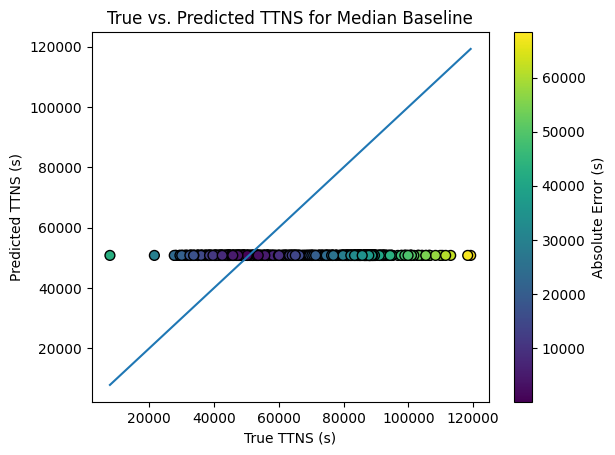

Sample0: True = 87270.00s, Predicted = 83970.00s, Error=3300.00s
Sample1: True = 33150.00s, Predicted = 87270.00s, Error=54120.00s
Sample2: True = 63240.00s, Predicted = 33150.00s, Error=30090.00s
Sample3: True = 83475.00s, Predicted = 63240.00s, Error=20235.00s
Sample4: True = 30930.00s, Predicted = 83475.00s, Error=52545.00s
Sample5: True = 64215.00s, Predicted = 30930.00s, Error=33285.00s
Sample6: True = 80820.00s, Predicted = 64215.00s, Error=16605.00s
Sample7: True = 29430.00s, Predicted = 80820.00s, Error=51390.00s
Sample8: True = 57720.00s, Predicted = 29430.00s, Error=28290.00s
Sample9: True = 86460.00s, Predicted = 57720.00s, Error=28740.00s
Sample10: True = 40245.00s, Predicted = 86460.00s, Error=46215.00s
Sample11: True = 48015.00s, Predicted = 40245.00s, Error=7770.00s
Sample12: True = 84210.00s, Predicted = 48015.00s, Error=36195.00s
Sample13: True = 51780.00s, Predicted = 84210.00s, Error=32430.00s
Sample14: True = 39585.00s, Predicted = 51780.00s, Error=12195.00s
Sample1

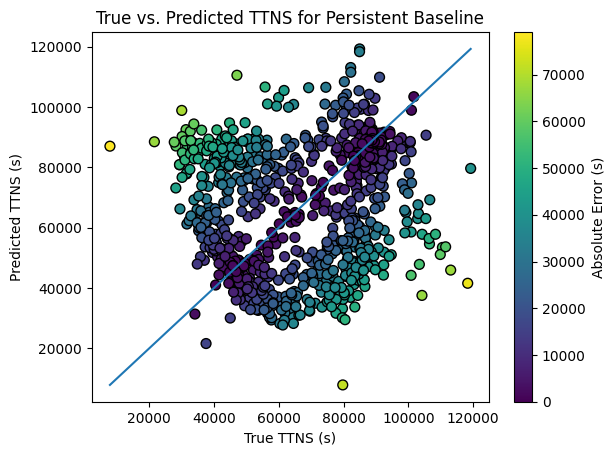

In [4]:
# Baseline Analysis: Median
y_test_secs = y_test_original
y_pred_secs = y_predicted_median

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Median Baseline")
plt.show()

# Persistent Baseline
y_test_secs = y_actual
y_pred_secs = y_predicted_presist

absolute_error_secs = np.abs(y_pred_secs - y_test_secs)

for i, (true, pred, abs_error) in enumerate(zip(y_test_secs, y_pred_secs, absolute_error_secs)):
  print(f"Sample{i}: True = {true:.2f}s, Predicted = {pred:.2f}s, Error={abs_error:.2f}s")

# Scatter plot of predicted vs true
plt.figure()
plt.scatter(y_test_secs, y_pred_secs, c=absolute_error_secs, cmap='viridis', s=50, edgecolors="black")
plt.colorbar(label="Absolute Error (s)")
plt.plot([min(y_test_secs), max(y_test_secs)], [min(y_test_secs), max(y_test_secs)])
plt.xlabel("True TTNS (s)")
plt.ylabel("Predicted TTNS (s)")
plt.title("True vs. Predicted TTNS for Persistent Baseline")
plt.show()